In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.table import Table
from scipy.interpolate import interp1d
dat = Table.read('/home/noah/Downloads/imaging_systematics_maps_and_weights_256.fits')
dndz = np.genfromtxt('/home/noah/Downloads/main_lrg_pz_dndz_iron_v0.4_dz_0.01.txt')
z = (dndz[:,0]+dndz[:,1])/2
dndz = dndz[:,3]
nside = 256
hpxid = dat['HPXPIXEL']
weights_1 = np.zeros(12*nside**2)-1
weights_2 = np.zeros(12*nside**2)-1
weights_3 = np.zeros(12*nside**2)-1
weights_4 = np.zeros(12*nside**2)-1
weights_1[hpxid] = dat['main_bin_1_weights']
weights_2[hpxid] = dat['main_bin_2_weights']
weights_3[hpxid] = dat['main_bin_3_weights']
weights_4[hpxid] = dat['main_bin_4_weights']
mask = 1.*(weights_1>-1)*(weights_2>-1)*(weights_3>-1)*(weights_4>-1)
I = np.where(mask==1.)
J = np.where(mask==0.)

redshifts = np.array([0.47,0.62,0.78,0.91])
weights = np.array([weights_1,weights_2,weights_3,weights_4])
wmap = lambda z: np.nan_to_num(interp1d(redshifts,weights,axis=0,kind='linear',fill_value="extrapolate")(z))

The actual systematics weight map for the $i$'th sample is

$$W_i(\hat{n}) = \frac{\int dz\, W(\hat{n},z)\bar{N}_i(z)}{\int dz\, \bar{N}_i(z)}$$

where $\bar{N}_i(z)$ is the redshift distribution of the $i$'th sample. Define $\hat{W}(\hat{n},z) = \sum_i f_i(z) W_i(\hat{n})$ for some coefficients $f_i(z)$ as the estimator for the full 3D systematics weight map?


$$\phi(\hat{n},z) = \frac{W(\hat{n},z)\bar{N}_i(z)}{\int dz\, W(\hat{n},z) \bar{N}_i(z)}$$

In [2]:
dz = z[1]-z[0]
norm = np.dot(dndz,np.array([wmap(zz) for zz in z]))*dz

In [3]:
phi = lambda zz: wmap(zz)*interp1d(z,dndz)(zz)/(norm+1e-10)
def dphi(zz):
    p = phi(zz)
    p[I] -= np.mean(p[I])
    p[J] = 0.
    return p

dphi_integral = np.sum(np.array([dphi(zz) for zz in z]),axis=0)*dz

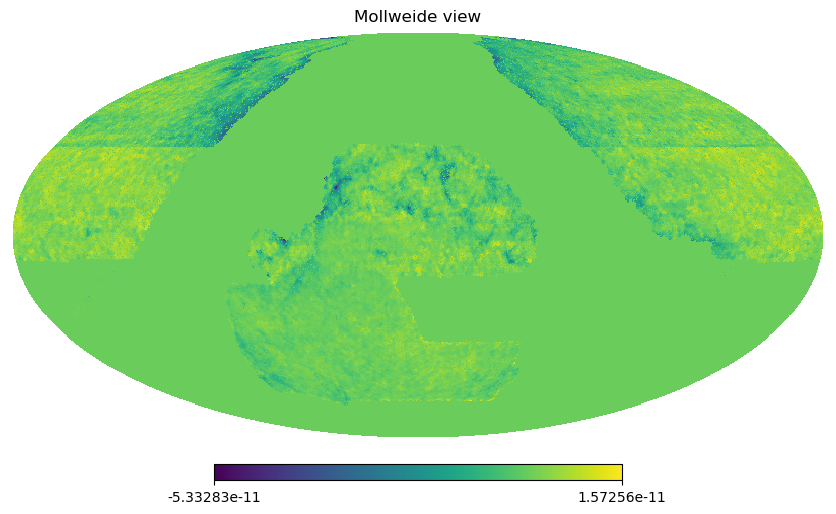

In [4]:
hp.mollview(dphi_integral)